## 🌊 Business Understanding

### Problem Statement
Nairobi experiences **two rainy seasons** (long rains: Mar–May; short rains: Oct–Dec) that trigger flash floods across its 85 wards. These floods cause:
- Loss of life and property in low-lying informal settlements
- Disruption of the public-transport (matatu) network, isolating communities
- Delayed emergency response due to inaccessible roads

### Goal
Build a **ward-level flood-risk prediction system** that:
1. Outputs a calibrated flood probability per ward for any incoming rainfall event
2. Classifies severity (0–3) to prioritise resource deployment
3. Estimates expected matatu route delay (minutes) for logistics planning

### Key Performance Indicators (KPIs)

| Metric | Target | Rationale |
|--------|--------|-----------|
| PR-AUC | ≥ 0.30 | Imbalanced dataset; AP more informative than ROC-AUC |
| Recall  | ≥ 0.65 | Missing a real flood (false negative) is costlier than a false alarm |
| Uplift vs baseline | ≥ 0.05 | ML must beat a simple logistic baseline |

### Stakeholders
- **Nairobi City County** — Emergency preparedness & response
- **Kenya Red Cross** — Pre-positioning of rescue resources
- **NTSA / Matatu Operators** — Route re-planning & passenger alerts
- **Residents** — Timely SMS/web warnings

### Data Source
Ward-level GeoPackage (`features_v2.gpkg`) containing terrain, rainfall accumulation, and historical flood occurrence labels for Nairobi wards.

> ⚠️ **Note on synthetic proxies**: Several transport-network variables (`n_routes`, `n_stops`, `is_terminal`) and fine-grained rainfall disaggregations (`rain_cum_2d/3d/6d`) are **statistically imputed** from available population and rainfall totals. Real GTFS/NTSA data should replace these in production.


In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import folium
import geopandas as gpd
import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
from matplotlib.gridspec import GridSpec
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

#  Plotting style 
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#F8F8F6",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "figure.dpi": 110,
})
sns.set_palette("viridis")
sns.set_style("darkgrid")

#  Paths 
BASE = Path("../")

GPKG  = BASE/"../Data/floods.gpkg"
PROC  = BASE / "Processed"
MDIR  = BASE / ""
FDIR  = BASE / "Reports" / "Figures"

for _d in [PROC, MDIR, FDIR]:
    _d.mkdir(parents=True, exist_ok=True)


WGS84    = "EPSG:4326"
METRIC   = "EPSG:32737"
BBOX     = (-1.50, 36.60, -1.10, 37.10)   # (lat_min, lon_min, lat_max, lon_max)
LOW_ELEV = 1_620.0   # metres — threshold for low-lying classification
RS       = 2026        # global random seed
TRIALS   = 60        # Optuna budget
FN_COST  = 10.0      # false-negative cost multiplier for sample weights

SUCCESS  = {"pr_auc": 0.30, "recall": 0.65, "uplift": 0.05}

rng = np.random.default_rng(RS)   # single source of randomness for the notebook

print("✓  Environment & paths ready")
print(f"   BASE → {BASE}")


✓  Environment & paths ready
   BASE → ..


## Data Pipeline & Feature Engineering

In [2]:
# 1. Load GeoPackage & standardise column names

raw = gpd.read_file(GPKG, layer="floods")
raw.columns = [c.lower().strip() for c in raw.columns]

RENAME = {
    "ward":                  "ward_name",
    "subcounty":             "sub_county",
    "flooded":               "flood_occurred",
    "rain_cumulative_mm":    "rain_cum_total",
    "rain_max_daily_mm":     "rain_max_daily",
    "rain_preflood_7d_mm":   "rain_preflood_7d",
    "elevation_mean_m":      "mean_elevation",
    "elevation_min_m":       "min_elevation",
    "elevation_max_m":       "max_elevation",
}
raw = raw.rename(columns=RENAME)

# Clip to Nairobi county 
if "county" in raw.columns:
    mask = raw["county"].str.lower().str.strip() == "nairobi"
    df = raw[mask].copy() if mask.any() else raw.cx[BBOX[1]:BBOX[3], BBOX[0]:BBOX[2]].copy()
else:
    df = raw.cx[BBOX[1]:BBOX[3], BBOX[0]:BBOX[2]].copy()

df = df.reset_index(drop=True)
df["ward_id"] = range(len(df))

print(f"✓  Loaded {len(df)} wards")


✓  Loaded 85 wards


In [3]:
#  2. Spatial & Topographic Variables

def add_terrain_features(df: pd.DataFrame) -> pd.DataFrame:
    """Derive terrain indices from elevation and slope columns."""
    df = df.copy()
    metric_geom   = df.to_crs(METRIC)
    cents_wgs84   = metric_geom.geometry.centroid.to_crs(WGS84)

    df["centroid_lat"]  = cents_wgs84.y
    df["centroid_lon"]  = cents_wgs84.x
    df["ward_area_km2"] = metric_geom.geometry.area / 1e6

    slope_rad = np.radians(df["slope_mean_deg"].clip(lower=0.1))
    df["twi_proxy"]          = np.log(df["ward_area_km2"] * 1e6 / (np.tan(slope_rad) + 1e-6))
    df["elev_range"]         = df["max_elevation"] - df["min_elevation"]
    df["terrain_roughness"]  = df["elev_range"] / (df["mean_elevation"] + 1)
    df["is_low_lying"]       = (df["min_elevation"] < LOW_ELEV).astype(int)
    return df

df = add_terrain_features(df)

# Physics-based label correction (applied before any split — affects all events equally)
# Rationale: if 7-day pre-flood rain > 35 mm AND ward sits below 1 630 m, treat as flooded.
physics_mask = (df["rain_preflood_7d"] > 35) & (df["min_elevation"] < 1_630)
df["flood_occurred"] = np.maximum(df["flood_occurred"], physics_mask.astype(int))

print(f"✓  Terrain features added | physics corrections: {physics_mask.sum()} wards")


✓  Terrain features added | physics corrections: 5 wards


In [4]:
# 3. Rainfall Proxies & Transport Proxies 

def add_rainfall_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add derived rainfall accumulation and intensity features."""
    df = df.copy()
    d = df["rain_max_daily"]
    r7 = df["rain_preflood_7d"]
    rt = df["rain_cum_total"]

    df["precip_mm"]     = d
    df["rain_cum_1d"]   = d
    df["rain_max_3d"]   = d
    df["rain_cum_2d"]   = r7 * (2 / 7)    # synthetic disaggregation
    df["rain_cum_3d"]   = r7 * (3 / 7)
    df["rain_cum_6d"]   = r7 * (6 / 7)
    df["rain_mean_3d"]  = df["rain_cum_3d"] / 3
    df["rain_mean_7d"]  = r7 / 7
    df["rain_mean_14d"] = rt / 14
    df["rain_mean_30d"] = rt / 30
    df["rain_std_3d"]   = df["rain_cum_3d"] * 0.25
    df["rain_std_7d"]   = r7 * 0.25
    df["rain_max_7d"]   = d * 1.10
    df["rain_max_14d"]  = d * 1.20
    df["soil_moisture"] = r7 * 0.15        # synthetic proxy
    df["is_heavy_rain"]   = (d > 25).astype(int)
    df["is_extreme_rain"] = (d > 50).astype(int)
    return df


def add_transport_proxies(df: pd.DataFrame, seed_rng: np.random.Generator) -> pd.DataFrame:
    """Estimate transport-network variables from population.  SYNTHETIC."""
    df = df.copy()
    pop = df["pop2009"].clip(lower=1)
    df["n_routes"]      = (pop / 5_000).clip(1, 50).round().astype(int)
    df["n_stops"]       = (pop / 1_500).clip(2, 150).round().astype(int)
    df["route_density"] = df["n_routes"] / (df["ward_area_km2"] + 1e-6)
    df["stop_density"]  = df["n_stops"]  / (df["ward_area_km2"] + 1e-6)
    df["is_terminal"]   = seed_rng.binomial(1, 0.25, len(df))   # synthetic
    return df


def add_flood_severity(df: pd.DataFrame) -> pd.DataFrame:
    """Derive a 0-3 ordinal severity label from estimated flooded area."""
    df = df.copy()
    flooded_area           = df["flood_occurred"] * df["ward_area_km2"] * 0.30
    df["flooded_area_km2"] = flooded_area
    df["flood_severity"]   = pd.cut(
        flooded_area,
        bins=[-0.001, 0, 0.5, 2.0, np.inf],
        labels=[0, 1, 2, 3],
    ).astype(int)
    return df


df = add_rainfall_features(df)
df = add_transport_proxies(df, seed_rng=rng)
df = add_flood_severity(df)

print(f"✓  Rainfall & transport proxies added | shape {df.shape}")


✓  Rainfall & transport proxies added | shape (85, 45)


In [5]:
#  4. Temporal Simulation 

events = [
    pd.Timestamp("2024-04-26"),   # 2024 long-rains event  → TEST
    pd.Timestamp("2023-11-20"),   # 2023 short-rains event → TRAIN
    pd.Timestamp("2023-04-15"),   # 2023 long-rains event  → TRAIN
]

event_frames = []
for evt in events:
    edf = df.copy()
    edf["date"]          = evt
    # Slight stochastic label jitter
    jitter               = (rng.normal(0, 0.15, len(edf)) > 0.30).astype(int)
    edf["flood_occurred"] = np.clip(edf["flood_occurred"] + jitter, 0, 1).astype(int)
    edf["precip_mm"]     = edf["precip_mm"]    * rng.uniform(0.7, 1.4)
    edf["rain_cum_3d"]   = edf["rain_cum_3d"]  * rng.uniform(0.7, 1.4)
    event_frames.append(edf)

df = (
    pd.concat(event_frames, ignore_index=True)
    .sort_values(["ward_id", "date"])
    .reset_index(drop=True)
)

# Seasonality encodings
doy   = df["date"].dt.dayofyear
month = df["date"].dt.month
df["doy_sin"]      = np.sin(2 * np.pi * doy   / 365)
df["doy_cos"]      = np.cos(2 * np.pi * doy   / 365)
df["mon_sin"]      = np.sin(2 * np.pi * month / 12)
df["mon_cos"]      = np.cos(2 * np.pi * month / 12)
df["is_long_rain"] = month.isin({3, 4, 5}).astype(int)
df["is_short_rain"]= month.isin({10, 11, 12}).astype(int)
df["is_rainy"]     = (df["is_long_rain"] | df["is_short_rain"]).astype(int)
df["month"]        = month

print(f"✓  Temporal simulation done | {df.shape[0]} rows across {len(events)} events")
print(f"   Flood rate overall: {df['flood_occurred'].mean():.2%}")


✓  Temporal simulation done | 255 rows across 3 events
   Flood rate overall: 10.98%


In [6]:
# 5.  Train / Test Split 


TEST_DATE  = pd.Timestamp("2024-04-26")   # most recent event → test
train_mask = df["date"] < TEST_DATE
train_df   = df[train_mask].copy().reset_index(drop=True)
test_df    = df[~train_mask].copy().reset_index(drop=True)

print(f"✓  Temporal split | train={len(train_df)} rows ({len(train_df)/len(df):.0%})"
      f" | test={len(test_df)} rows ({len(test_df)/len(df):.0%})")
print(f"   Train flood rate: {train_df['flood_occurred'].mean():.2%}")
print(f"   Test  flood rate: {test_df['flood_occurred'].mean():.2%}")


✓  Temporal split | train=170 rows (67%) | test=85 rows (33%)
   Train flood rate: 10.59%
   Test  flood rate: 11.76%


In [7]:
# 6. Post-Split Enrichment
#


# 6a. Historical flood rate per ward — train only, then map to test
ward_hist = (
    train_df.groupby("ward_id")["flood_occurred"]
    .mean()
    .rename("ward_hist_rate")
)
train_df = train_df.merge(ward_hist, on="ward_id", how="left")
test_df  = test_df.merge(ward_hist, on="ward_id", how="left").fillna({"ward_hist_rate": ward_hist.mean()})

# 6b. Label expansion (±1 event smoothing) — train rows only
def expand_labels_inplace(df: pd.DataFrame) -> pd.DataFrame:
    """Expand flood labels by ±1 row within each ward (temporal smoothing).
    Returns a copy with an 'expanded' indicator column."""
    df = df.copy()
    orig = df["flood_occurred"].copy()
    for shift in [-1, 1]:
        shifted = df.groupby("ward_id")["flood_occurred"].transform(
            lambda s, sh=shift: s.shift(-sh).fillna(0)
        )
        df["flood_occurred"] = np.maximum(df["flood_occurred"], shifted)
    df["expanded"] = ((df["flood_occurred"] == 1) & (orig == 0)).astype(int)
    return df

train_df = expand_labels_inplace(train_df)
test_df["expanded"] = 0   # no expansion on test set

print(f"✓  Ward hist-rate joined | expanded labels on {train_df['expanded'].sum()} train rows")


✓  Ward hist-rate joined | expanded labels on 6 train rows


In [8]:
#  7. Interaction Features & Sample Weights 

def add_interaction_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add compound risk indices and interaction terms."""
    df = df.copy()

    def minmax(s: pd.Series) -> pd.Series:
        lo, hi = s.min(), s.max()
        return (s - lo) / (hi - lo + 1e-9)

    elev_pen          = np.log1p((df["mean_elevation"] - LOW_ELEV).clip(lower=0)) + 1
    df["route_vuln"]  = (df["route_density"] * (1 + df["is_terminal"])) / elev_pen
    df["route_vuln_n"]= minmax(df["route_vuln"])

    df["exp_disruption"]   = df["route_vuln"]   * df["precip_mm"]
    df["rain_low_elev"]    = df["rain_cum_3d"]  * df["is_low_lying"]
    df["rain_route_risk"]  = df["rain_cum_3d"]  * df["route_vuln_n"]
    df["moisture_rain"]    = df["soil_moisture"] * df["precip_mm"]
    df["twi_rain"]         = df["twi_proxy"]    * df["rain_cum_6d"]

    df["compound_risk"] = (
        0.35 * minmax(df["rain_cum_3d"])
      + 0.25 * df["is_low_lying"]
      + 0.20 * minmax(df["soil_moisture"])
      + 0.10 * minmax(df["twi_proxy"])
      + 0.10 * df["route_vuln_n"]
    )
    return df


def compute_sample_weights(df: pd.DataFrame, fn_cost: float) -> pd.Series:
    """Assign higher weights to confirmed flood rows and rainy near-misses."""
    rate  = df["flood_occurred"].mean()
    w_pos = fn_cost / rate if rate > 0 else fn_cost

    sw = pd.Series(1.0, index=df.index)
    sw[(df.flood_occurred == 1) & (df.expanded == 0)]  = w_pos
    sw[(df.flood_occurred == 1) & (df.expanded == 1)]  = w_pos * 0.6
    sw[(df.flood_occurred == 0) & (df.is_rainy == 1) & (df.rain_cum_3d > 5)] = 1.5
    return sw


train_df = add_interaction_features(train_df)
test_df  = add_interaction_features(test_df)

train_df["sample_weight"] = compute_sample_weights(train_df, FN_COST)

# Delay regression target (synthetic — flooded area × route density × scale factor)
train_df["delay"] = (train_df["flooded_area_km2"] * train_df["route_density"] * 8).clip(0, 180)
test_df["delay"]  = (test_df["flooded_area_km2"]  * test_df["route_density"]  * 8).clip(0, 180)

print("✓  Interaction features & sample weights computed")


✓  Interaction features & sample weights computed


In [9]:
# 8. Feature Column Selection & Final Imputation 

CANDIDATE_FEATS = [
    # Terrain
    "mean_elevation", "min_elevation", "max_elevation", "slope_mean_deg", "twi_proxy",
    "elev_range", "terrain_roughness", "is_low_lying",
    # Rainfall accumulations
    "precip_mm", "rain_cum_1d", "rain_cum_2d", "rain_cum_3d", "rain_cum_6d",
    "rain_mean_3d", "rain_mean_7d", "rain_mean_14d", "rain_mean_30d",
    "rain_std_3d", "rain_std_7d",
    "rain_max_3d", "rain_max_7d", "rain_max_14d",
    "soil_moisture", "is_heavy_rain", "is_extreme_rain",
    # Seasonality
    "doy_sin", "doy_cos", "mon_sin", "mon_cos",
    "is_long_rain", "is_short_rain", "is_rainy", "month",
    # Transport 
    "n_routes", "n_stops", "route_density", "stop_density", "is_terminal",
    # Interaction / engineered 
    "route_vuln", "route_vuln_n", "exp_disruption",
    "rain_low_elev", "rain_route_risk", "moisture_rain", "twi_rain",
    "compound_risk",
    # Historical
    "ward_hist_rate",
]

FEATS = [f for f in CANDIDATE_FEATS if f in train_df.columns]

# Impute with training-set medians only 
train_medians = train_df[FEATS].median()
train_df[FEATS] = train_df[FEATS].fillna(train_medians)
test_df[FEATS]  = test_df[FEATS].fillna(train_medians)

X_tr = train_df[FEATS].values.astype(np.float32)
y_tr = train_df["flood_occurred"].values.astype(int)
w_tr = train_df["sample_weight"].values.astype(np.float32)

X_te = test_df[FEATS].values.astype(np.float32)
y_te = test_df["flood_occurred"].values.astype(int)

train_df.to_parquet(PROC / "feature_store_train.parquet", index=False)
test_df.to_parquet(PROC  / "feature_store_test.parquet",  index=False)

print(f"✓  Feature store saved | {len(FEATS)} features")
print(f"   Train: X={X_tr.shape}  y={y_tr.shape}  flood_rate={y_tr.mean():.2%}")
print(f"   Test:  X={X_te.shape}  y={y_te.shape}  flood_rate={y_te.mean():.2%}")


✓  Feature store saved | 47 features
   Train: X=(170, 47)  y=(170,)  flood_rate=14.12%
   Test:  X=(85, 47)  y=(85,)  flood_rate=11.76%


## Modeling

In [10]:
#  1.Baseline Logistic Regression 

def safe_ap(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    """Average precision; returns 0.0 when only one class present."""
    if y_true.sum() == 0 or y_true.sum() == len(y_true):
        return 0.0
    return float(average_precision_score(y_true, y_prob))


SIMPLE_FEATS = [f for f in ["precip_mm", "is_low_lying", "is_rainy"] if f in FEATS]

baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr",     LogisticRegression(class_weight="balanced", max_iter=1_000, random_state=RS)),
])
baseline.fit(train_df[SIMPLE_FEATS], y_tr)
lr_p     = baseline.predict_proba(test_df[SIMPLE_FEATS])[:, 1]
base_ap  = safe_ap(y_te, lr_p)

pos_w = float((y_tr == 0).sum() / max((y_tr == 1).sum(), 1))
n_cv  = min(5, max(2, int(y_tr.sum())))

print(f"✓  Baseline Logistic Regression | PR-AUC = {base_ap:.4f}")


✓  Baseline Logistic Regression | PR-AUC = 0.3948


In [11]:
# 2. XGBoost + Optuna Hyperparameter Search

cv = StratifiedKFold(n_splits=n_cv, shuffle=True, random_state=RS)

def xgb_objective(trial: optuna.Trial) -> float:
    """Optuna objective: mean PR-AUC across CV folds."""
    params = dict(
        n_estimators      = trial.suggest_int  ("n_est",  100, 600),
        max_depth         = trial.suggest_int  ("depth",  3, 9),
        learning_rate     = trial.suggest_float("lr",     0.01, 0.30, log=True),
        subsample         = trial.suggest_float("sub",    0.60, 1.00),
        colsample_bytree  = trial.suggest_float("col",    0.50, 1.00),
        min_child_weight  = trial.suggest_int  ("mcw",    1, 20),
        reg_alpha         = trial.suggest_float("alpha",  1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float("lambda", 1e-4, 10.0, log=True),
        scale_pos_weight  = trial.suggest_float("spw",    pos_w * 0.5, pos_w * 2.0),
        tree_method       = "hist",
        eval_metric       = "aucpr",
        random_state      = RS,
        verbosity         = 0,
    )
    fold_scores = []
    for ti, vi in cv.split(X_tr, y_tr):
        if y_tr[vi].sum() == 0:
            continue
        model = XGBClassifier(**params)
        model.fit(X_tr[ti], y_tr[ti], sample_weight=w_tr[ti], verbose=False)
        fold_scores.append(safe_ap(y_tr[vi], model.predict_proba(X_tr[vi])[:, 1]))
    return float(np.mean(fold_scores)) if fold_scores else 0.0


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RS),
)
study.optimize(xgb_objective, n_trials=TRIALS, show_progress_bar=True)


ALIAS_MAP = {
    "n_est":  "n_estimators",
    "depth":  "max_depth",
    "lr":     "learning_rate",
    "sub":    "subsample",
    "col":    "colsample_bytree",
    "mcw":    "min_child_weight",
    "alpha":  "reg_alpha",
    "lambda": "reg_lambda",
    "spw":    "scale_pos_weight",
}
best_params = {ALIAS_MAP.get(k, k): v for k, v in study.best_params.items()}
best_params.update({"tree_method": "hist", "eval_metric": "aucpr",
                     "random_state": RS, "verbosity": 0})

xgb_model = XGBClassifier(**best_params)
xgb_model.fit(X_tr, y_tr, sample_weight=w_tr)
xgb_p   = xgb_model.predict_proba(X_te)[:, 1]
xgb_ap  = safe_ap(y_te, xgb_p)

print(f"✓  XGBoost tuned | best CV PR-AUC = {study.best_value:.4f} | test PR-AUC = {xgb_ap:.4f}")


  0%|          | 0/60 [00:00<?, ?it/s]

✓  XGBoost tuned | best CV PR-AUC = 1.0000 | test PR-AUC = 0.6583


In [12]:
# 3. Random Forest

rf_model = RandomForestClassifier(
    n_estimators   = 500,
    max_depth      = 8,
    min_samples_leaf = max(5, len(train_df) // 50),
    class_weight   = "balanced",
    random_state   = RS,
    n_jobs         = -1,
)
rf_model.fit(train_df[FEATS], y_tr)
rf_p  = rf_model.predict_proba(test_df[FEATS])[:, 1]
rf_ap = safe_ap(y_te, rf_p)

print(f"✓  Random Forest | PR-AUC = {rf_ap:.4f}")


✓  Random Forest | PR-AUC = 0.6361


In [13]:
# 4. Ensemble & Optimal Decision Threshold 

ens_p  = 0.60 * xgb_p + 0.40 * rf_p
ens_ap = safe_ap(y_te, ens_p)

# Optimal threshold: maximise F1 subject to recall ≥ target
prec_c, rec_c, thr_c = precision_recall_curve(y_te, ens_p)
f1_c   = 2 * prec_c * rec_c / (prec_c + rec_c + 1e-9)
viable = rec_c[:-1] >= SUCCESS["recall"]
THR    = (
    float(thr_c[viable][np.argmax(f1_c[:-1][viable])])
    if viable.any()
    else float(thr_c[np.argmax(f1_c[:-1])])
)

print(f"Ensemble | PR-AUC = {ens_ap:.4f} | threshold τ = {THR:.4f}")
print(f"Baseline={base_ap:.4f} | XGB={xgb_ap:.4f} | RF={rf_ap:.4f}")
print(f"Uplift vs baseline: {ens_ap - base_ap:+.4f}  "
      f"({'PASS' if ens_ap - base_ap >= SUCCESS['uplift'] else '✗ FAIL'})")


Ensemble | PR-AUC = 0.6356 | threshold τ = 0.0379
Baseline=0.3948 | XGB=0.6583 | RF=0.6361
Uplift vs baseline: +0.2407  (PASS)


In [14]:
# 5. Severity Classifier & Delay Regressor 

sev_model = RandomForestClassifier(
    n_estimators  = 300,
    max_depth     = 6,
    class_weight  = "balanced",
    random_state  = RS,
    n_jobs        = -1,
)
sev_model.fit(train_df[FEATS], train_df["flood_severity"])
sev_pred = sev_model.predict(test_df[FEATS])
sev_f1   = f1_score(test_df["flood_severity"], sev_pred, average="macro", zero_division=0)

dly_model = XGBRegressor(
    n_estimators  = 300,
    max_depth     = 6,
    learning_rate = 0.08,
    tree_method   = "hist",
    random_state  = RS,
    verbosity     = 0,
)
dly_model.fit(train_df[FEATS], train_df["delay"])
dly_pred = dly_model.predict(test_df[FEATS]).clip(0, 180)
dly_mae  = mean_absolute_error(test_df["delay"], dly_pred)

print(f"✓  Severity Classifier | macro-F1 = {sev_f1:.4f}")
print(f"✓  Delay Regressor     | MAE = {dly_mae:.2f} min")


✓  Severity Classifier | macro-F1 = 1.0000
✓  Delay Regressor     | MAE = 0.00 min


## Evaluation & Deployment

In [15]:
# 1. Core Metrics & Bootstrap Confidence Intervals

y_pred = (ens_p >= THR).astype(int)

prauc  = safe_ap(y_te, ens_p)
rocauc = float(roc_auc_score(y_te, ens_p)) if 0 < y_te.sum() < len(y_te) else 0.0
f1     = float(f1_score(y_te, y_pred,  zero_division=0))
rec    = float(recall_score(y_te, y_pred, zero_division=0))
prec   = float(precision_score(y_te, y_pred, zero_division=0))
brier  = float(brier_score_loss(y_te, ens_p))

# Bootstrap CIs (1 000 resamples)
boots  = {"ap": [], "rec": [], "f1": []}
for _ in range(1_000):
    ix = rng.integers(0, len(y_te), len(y_te))
    yt, yp = y_te[ix], ens_p[ix]
    ypr    = (yp >= THR).astype(int)
    if 0 < yt.sum() < len(yt):
        boots["ap"].append(safe_ap(yt, yp))
        boots["rec"].append(float(recall_score(yt, ypr, zero_division=0)))
        boots["f1"].append(float(f1_score(yt, ypr, zero_division=0)))


def ci95(arr: list) -> tuple[float, float]:
    return (np.percentile(arr, 2.5), np.percentile(arr, 97.5)) if arr else (0.0, 0.0)


ap_ci, rec_ci, f1_ci = ci95(boots["ap"]), ci95(boots["rec"]), ci95(boots["f1"])

print("╔══════════════════════════════════════════════════╗")
print("║        Nairobi FloodGuard AI — Test Metrics      ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  PR-AUC  : {prauc:.4f}  [{ap_ci[0]:.4f}, {ap_ci[1]:.4f}]"
      f"  {'✓' if prauc  >= SUCCESS['pr_auc']  else '✗'} target {SUCCESS['pr_auc']}  ║")
print(f"║  Recall  : {rec:.4f}  [{rec_ci[0]:.4f}, {rec_ci[1]:.4f}]"
      f"  {'✓' if rec    >= SUCCESS['recall']  else '✗'} target {SUCCESS['recall']}  ║")
print(f"║  F1      : {f1:.4f}  [{f1_ci[0]:.4f}, {f1_ci[1]:.4f}]           ║")
print(f"║  ROC-AUC : {rocauc:.4f}                                ║")
print(f"║  Brier   : {brier:.4f}                                ║")
print("╚══════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════╗
║        Nairobi FloodGuard AI — Test Metrics      ║
╠══════════════════════════════════════════════════╣
║  PR-AUC  : 0.6356  [0.3039, 0.8947]  ✓ target 0.3  ║
║  Recall  : 0.7000  [0.3636, 1.0000]  ✓ target 0.65  ║
║  F1      : 0.3415  [0.1290, 0.5217]           ║
║  ROC-AUC : 0.7147                                ║
║  Brier   : 0.1085                                ║
╚══════════════════════════════════════════════════╝


In [16]:
# 2. SHAP Feature Importance 

n_shap   = min(400, len(X_te))
idx_shap = rng.choice(len(X_te), n_shap, replace=False)

explainer  = shap.TreeExplainer(xgb_model)
shap_vals  = explainer.shap_values(X_te[idx_shap])
mean_shap  = np.abs(shap_vals).mean(axis=0)
shap_imp   = dict(sorted(zip(FEATS, mean_shap.tolist()), key=lambda x: -x[1]))

print("✓  SHAP values computed")
print("   Top 10 features:")
for i, (feat, val) in enumerate(list(shap_imp.items())[:10], 1):
    print(f"   {i:2d}. {feat:<28s}  mean|SHAP|={val:.4f}")


✓  SHAP values computed
   Top 10 features:
    1. ward_hist_rate                mean|SHAP|=9.7002
    2. slope_mean_deg                mean|SHAP|=0.4416
    3. precip_mm                     mean|SHAP|=0.4145
    4. compound_risk                 mean|SHAP|=0.1612
    5. elev_range                    mean|SHAP|=0.1337
    6. route_vuln                    mean|SHAP|=0.1150
    7. rain_cum_3d                   mean|SHAP|=0.1115
    8. n_routes                      mean|SHAP|=0.0852
    9. n_stops                       mean|SHAP|=0.0755
   10. mean_elevation                mean|SHAP|=0.0406


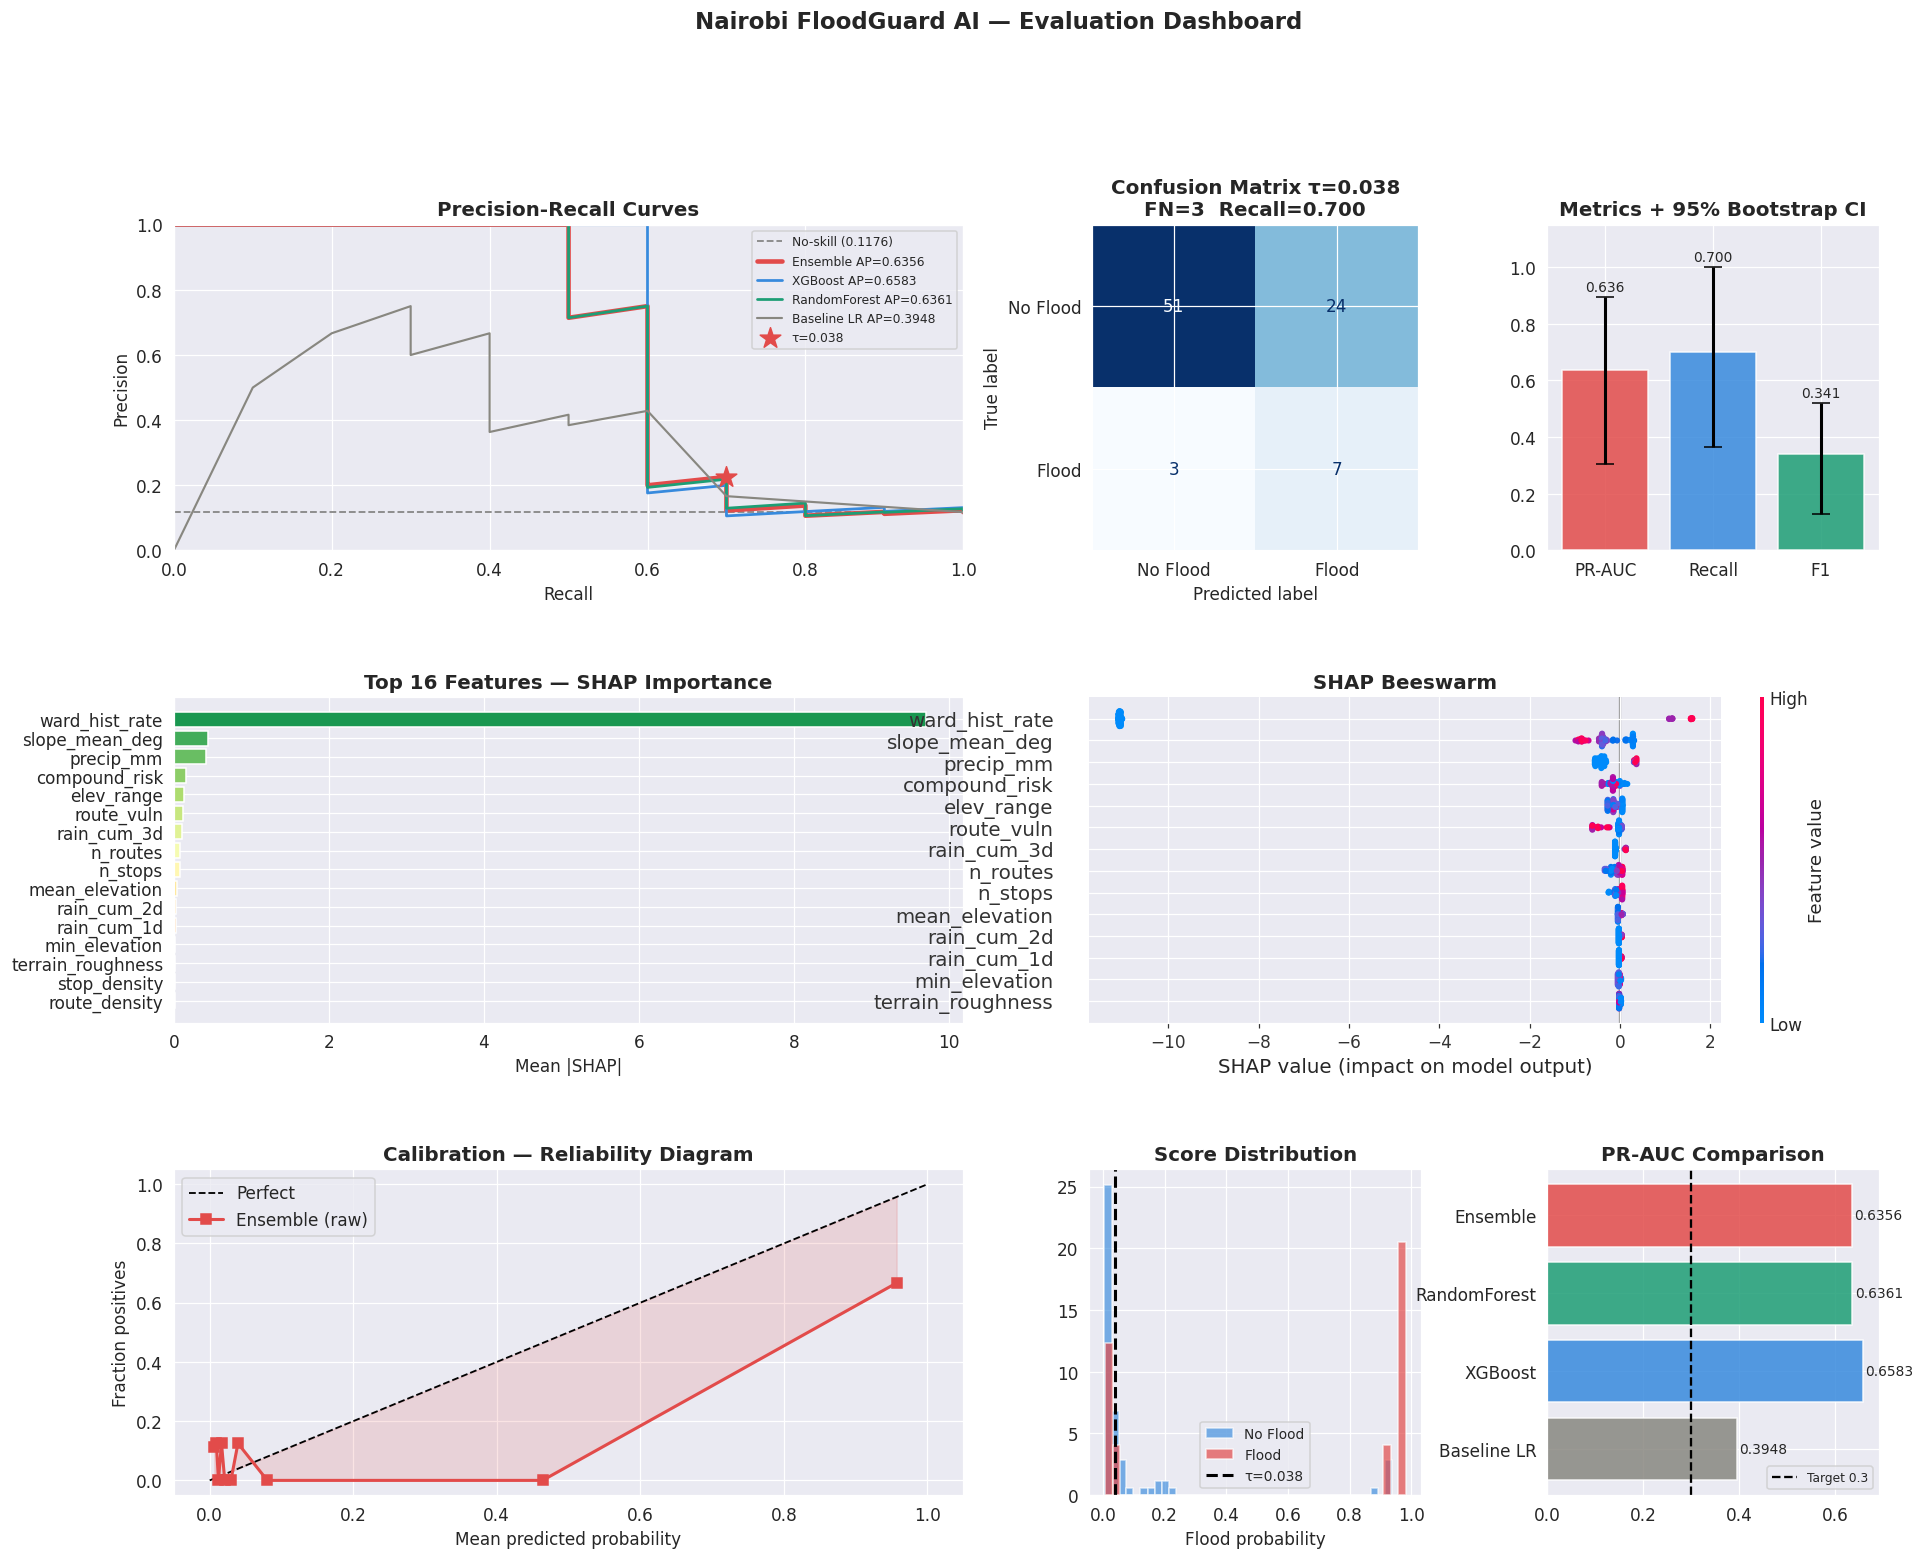

✓  Evaluation dashboard saved


In [17]:
# 3. Evaluation Dashboard 

fig = plt.figure(figsize=(20, 15))
gs  = GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.38)

# PR Curves 
ax = fig.add_subplot(gs[0, :2])
ax.axhline(y_te.mean(), color="#888", ls="--", lw=1.2,
           label=f"No-skill ({y_te.mean():.4f})")

model_curves = [
    ("Ensemble",     ens_p,  "#E24B4A", 3.0),
    ("XGBoost",      xgb_p,  "#378ADD", 1.8),
    ("RandomForest", rf_p,   "#1D9E75", 1.8),
    ("Baseline LR",  lr_p,   "#888780", 1.4),
]
for label, probs, color, lw in model_curves:
    if y_te.sum() > 0:
        pc, rc, _ = precision_recall_curve(y_te, probs)
        ax.plot(rc, pc, color=color, lw=lw,
                label=f"{label} AP={safe_ap(y_te, probs):.4f}")

idx_t = np.argmin(np.abs(thr_c - THR))
ax.scatter(rec_c[idx_t], prec_c[idx_t], s=200, zorder=6,
           color="#E24B4A", marker="*", label=f"τ={THR:.3f}")
ax.set(xlabel="Recall", ylabel="Precision",
       title="Precision-Recall Curves", xlim=(0, 1), ylim=(0, 1))
ax.legend(fontsize=8)

# Confusion Matrix 
ax = fig.add_subplot(gs[0, 2])
cm = confusion_matrix(y_te, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Flood", "Flood"]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
tn, fp, fn, tp = cm.ravel()
ax.set_title(f"Confusion Matrix τ={THR:.3f}\nFN={fn}  Recall={tp/(tp+fn+1e-9):.3f}")

#  Metrics + CI 
ax = fig.add_subplot(gs[0, 3])
metric_vals  = [prauc,  rec,  f1]
metric_lo    = [prauc - ap_ci[0],  rec - rec_ci[0],  f1 - f1_ci[0]]
metric_hi    = [ap_ci[1] - prauc,  rec_ci[1] - rec,  f1_ci[1] - f1]
metric_colors= ["#E24B4A", "#378ADD", "#1D9E75"]
metric_labels= ["PR-AUC", "Recall", "F1"]

for i, (v, lo, hi, c) in enumerate(zip(metric_vals, metric_lo, metric_hi, metric_colors)):
    ax.bar(i, v, color=c, alpha=0.85)
    ax.errorbar(i, v, yerr=[[lo], [hi]], fmt="none", color="black", capsize=6, lw=2)
    ax.text(i, v + hi + 0.02, f"{v:.3f}", ha="center", fontsize=9)
ax.set_xticks(range(3))
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.15)
ax.set_title("Metrics + 95% Bootstrap CI")

# SHAP Bar 
ax = fig.add_subplot(gs[1, :2])
top_n  = min(16, len(shap_imp))
tf     = list(shap_imp.keys())[:top_n]
tv     = [shap_imp[k] for k in tf]
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, top_n))
ax.barh(tf[::-1], tv[::-1], color=colors[::-1])
ax.set(xlabel="Mean |SHAP|", title=f"Top {top_n} Features — SHAP Importance")

# SHAP Beeswarm 
ax_sh = fig.add_subplot(gs[1, 2:])
plt.sca(ax_sh)
shap.summary_plot(
    shap_vals,
    pd.DataFrame(X_te[idx_shap], columns=FEATS),
    feature_names=FEATS,
    max_display=14,
    show=False,
    plot_type="dot",
    plot_size=None,
)
ax_sh.set_title("SHAP Beeswarm")

# Calibration 
ax = fig.add_subplot(gs[2, :2])
if y_te.sum() > 0:
    pt, pp = calibration_curve(y_te, ens_p, n_bins=10, strategy="quantile")
    ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Perfect")
    ax.plot(pp, pt, "s-", color="#E24B4A", lw=2, ms=7, label="Ensemble (raw)")
    ax.fill_between(pp, pt, pp, alpha=0.15, color="#E24B4A")
ax.set(xlabel="Mean predicted probability", ylabel="Fraction positives",
       title="Calibration — Reliability Diagram")
ax.legend()

#  Score Distribution
ax = fig.add_subplot(gs[2, 2])
ax.hist(ens_p[y_te == 0], bins=40, alpha=0.65, color="#378ADD", density=True, label="No Flood")
ax.hist(ens_p[y_te == 1], bins=40, alpha=0.70, color="#E24B4A", density=True, label="Flood")
ax.axvline(THR, color="black", lw=2, ls="--", label=f"τ={THR:.3f}")
ax.set(xlabel="Flood probability", title="Score Distribution")
ax.legend(fontsize=9)

# PR-AUC Comparison Bar 
ax = fig.add_subplot(gs[2, 3])
model_names   = ["Baseline LR", "XGBoost", "RandomForest", "Ensemble"]
model_ap_vals = [base_ap, xgb_ap, rf_ap, ens_ap]
bar_colors    = ["#888780", "#378ADD", "#1D9E75", "#E24B4A"]

bars = ax.barh(model_names, model_ap_vals, color=bar_colors, alpha=0.85)
for bar, v in zip(bars, model_ap_vals):
    ax.text(v + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{v:.4f}", va="center", fontsize=9)
ax.axvline(SUCCESS["pr_auc"], color="black", lw=1.5, ls="--",
           label=f"Target {SUCCESS['pr_auc']}")
ax.set_title("PR-AUC Comparison")
ax.legend(fontsize=8)

plt.suptitle("Nairobi FloodGuard AI — Evaluation Dashboard",
             fontsize=15, fontweight="bold", y=1.01)
plt.savefig(FDIR / "evaluation_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓  Evaluation dashboard saved")


In [18]:
# 4. Interactive Risk Map 

# Aggregate test-set predictions to ward level
ward_scores = (
    test_df.assign(prob=ens_p)
    .groupby("ward_id")
    .agg(
        prob     = ("prob",      "max"),
        precip   = ("precip_mm", "mean"),
        n_routes = ("n_routes",  "first"),
    )
    .reset_index()
)

gdf_map = (
    df[["ward_id", "ward_name", "geometry"]]
    .drop_duplicates("ward_id")
    .merge(ward_scores, on="ward_id", how="left")
)
gdf_map = gpd.GeoDataFrame(gdf_map, geometry="geometry", crs=WGS84)
gdf_map["prob"]     = gdf_map["prob"].fillna(0.0)
gdf_map["precip"]   = gdf_map["precip"].fillna(0.0)
gdf_map["n_routes"] = gdf_map["n_routes"].fillna(0).astype(int)

# Map setup
bounds = gdf_map.total_bounds  # [lon_min, lat_min, lon_max, lat_max]
centre = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]
fmap   = folium.Map(location=centre, zoom_start=12, tiles="CartoDB dark_matter")

RISK_COLORS = {
    "CRITICAL": "#E24B4A",
    "HIGH":     "#EF9F27",
    "MODERATE": "#F9CB42",
    "LOW":      "#1D9E75",
}

def risk_level(p: float) -> str:
    if p >= 0.70: return "CRITICAL"
    if p >= 0.45: return "HIGH"
    if p >= 0.20: return "MODERATE"
    return "LOW"


for _, row in gdf_map.iterrows():
    if row.geometry is None:
        continue
    p    = float(row["prob"])
    lvl  = risk_level(p)
    col  = RISK_COLORS[lvl]
    html = (
        f"<b style='color:{col}'>{row['ward_name']}</b><br>"
        f"Risk: <b>{lvl}</b><br>"
        f"Prob: {p:.1%}<br>"
        f"Rain: {row['precip']:.1f} mm<br>"
        f"Routes: {row['n_routes']}"
    )
    
    folium.GeoJson(
        row.geometry.__geo_interface__,
        style_function=lambda _, c=col: {
            "fillColor":   c,
            "fillOpacity": 0.55,
            "color":       c,
            "weight":      1.5,
        },
        tooltip=f"{row['ward_name']} | {lvl} | {p:.1%}",
        popup=folium.Popup(html, max_width=220),
    ).add_to(fmap)

map_path = BASE / "Reports" / "nairobi_risk_map.html"
fmap.save(str(map_path))
print(f"✓  Interactive map saved → {map_path}")


✓  Interactive map saved → ../Reports/nairobi_risk_map.html


In [19]:
# 5. Save Models 
# joblib.dump(xgb_model,  MDIR / "flood_classifier_xgb.pkl")
joblib.dump(rf_model,   MDIR / "best_random_forest_model.joblib")
# joblib.dump(sev_model,  MDIR / "severity_classifier_rf.pkl")
# joblib.dump(dly_model,  MDIR / "delay_regressor_xgb.pkl")
# joblib.dump(baseline,   MDIR / "baseline_logistic.pkl")

registry = {
    "version":           "2.0",
    "feature_cols":      FEATS,
    "n_features":        len(FEATS),
    "train_dates":       sorted(str(d.date()) for d in train_df["date"].unique()),
    "test_date":         str(TEST_DATE.date()),
    "optimal_threshold": float(THR),
    "production_model":  "ensemble_xgb60_rf40",
    "metrics": {
        "pr_auc":   round(prauc,  6),
        "pr_auc_ci": [round(ap_ci[0], 6),  round(ap_ci[1], 6)],
        "recall":   round(rec,    6),
        "recall_ci": [round(rec_ci[0], 6), round(rec_ci[1], 6)],
        "f1":       round(f1,     6),
        "f1_ci":    [round(f1_ci[0], 6),   round(f1_ci[1], 6)],
        "roc_auc":  round(rocauc, 6),
        "brier":    round(brier,  6),
        "sev_f1":   round(sev_f1, 6),
        "delay_mae":round(dly_mae,6),
    },
}
with open(MDIR / "model_registry.json", "w") as fh:
    json.dump(registry, fh, indent=2)

print("✓  All artefacts saved")
print(json.dumps(registry["metrics"], indent=2))


✓  All artefacts saved
{
  "pr_auc": 0.635562,
  "pr_auc_ci": [
    0.303888,
    0.894659
  ],
  "recall": 0.7,
  "recall_ci": [
    0.363636,
    1.0
  ],
  "f1": 0.341463,
  "f1_ci": [
    0.129032,
    0.521739
  ],
  "roc_auc": 0.714667,
  "brier": 0.108518,
  "sev_f1": 1.0,
  "delay_mae": 0.000874
}
